In [ ]:
# Task 2: Exploratory Data Analysis
# Ethiopia Financial Inclusion Forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
print("Please upload ethiopia_fi_unified_data.xlsx")
uploaded = files.upload()

import os
raw_data_path = None
for filename in uploaded.keys():
    if 'ethiopia_fi_unified_data' in filename:
        raw_data_path = filename
        break

df = pd.read_excel(raw_data_path)
print(f"Data loaded: {df.shape}")

Mounted at /content/drive
Please upload ethiopia_fi_unified_data.xlsx


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data.xlsx
Data loaded: (43, 34)


In [ ]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nRecord types:")
print(df['record_type'].value_counts())

print(f"\nPillars:")
print(df['pillar'].value_counts())

print(f"\nDate range:")
if 'observation_date' in df.columns:
    print(f"  {df['observation_date'].min()} to {df['observation_date'].max()}")

DATASET OVERVIEW
Total records: 43
Columns: ['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Record types:
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

Pillars:
pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

Date range:
  2014-12-31 00:00:00 to 2030-12-31 00:00:00


In [ ]:
observations = df[df['record_type'] == 'observation']
events = df[df['record_type'] == 'event']
impact_links = df[df['record_type'] == 'impact_link']
targets = df[df['record_type'] == 'target']

print(f"Observations: {len(observations)}")
print(f"Events: {len(events)}")
print(f"Impact Links: {len(impact_links)}")
print(f"Targets: {len(targets)}")

Observations: 30
Events: 10
Impact Links: 0
Targets: 3


ACCESS ANALYSIS - ACCOUNT OWNERSHIP TREND


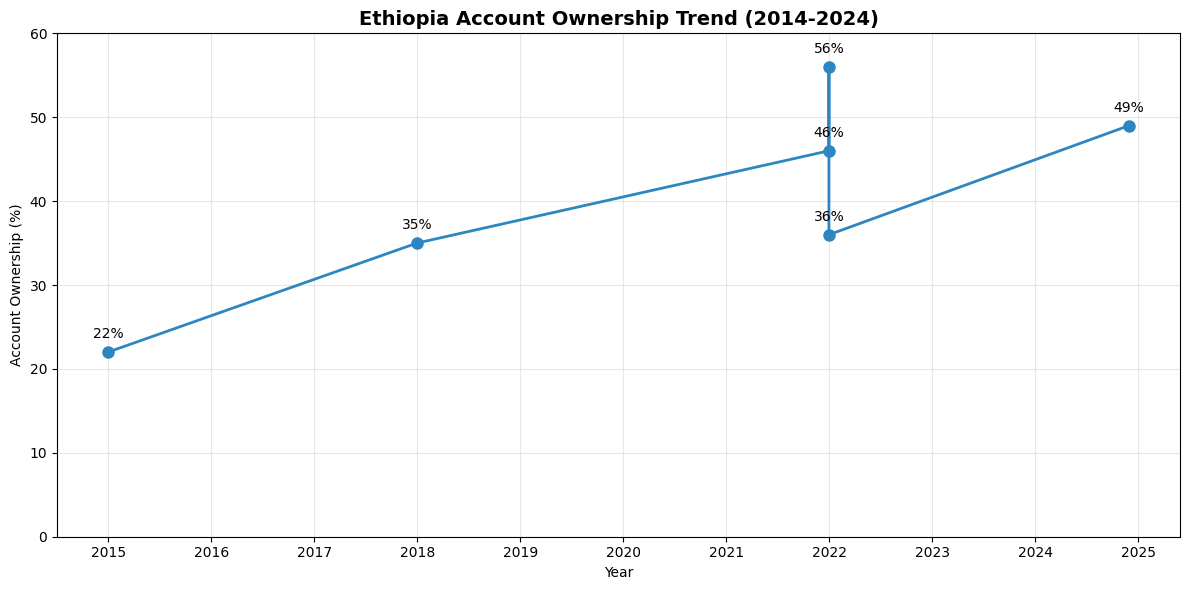


Account Ownership Data:
  observation_date  value_numeric         source_name
0       2014-12-31           22.0  Global Findex 2014
1       2017-12-31           35.0  Global Findex 2017
2       2021-12-31           46.0  Global Findex 2021
3       2021-12-31           56.0  Global Findex 2021
4       2021-12-31           36.0  Global Findex 2021
5       2024-11-29           49.0  Global Findex 2024


In [ ]:
print("=" * 80)
print("ACCESS ANALYSIS - ACCOUNT OWNERSHIP TREND")
print("=" * 80)

access_data = observations[observations['pillar'] == 'ACCESS']
access_ownership = access_data[access_data['indicator_code'] == 'ACC_OWNERSHIP']

if len(access_ownership) > 0:
    access_ownership = access_ownership.sort_values('observation_date')

    plt.figure(figsize=(12, 6))
    plt.plot(access_ownership['observation_date'], access_ownership['value_numeric'],
             marker='o', linewidth=2, markersize=8, color='#2e86c1')
    plt.title('Ethiopia Account Ownership Trend (2014-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Account Ownership (%)')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 60)

    for i, row in access_ownership.iterrows():
        plt.annotate(f"{row['value_numeric']:.0f}%",
                    (row['observation_date'], row['value_numeric']),
                    textcoords="offset points", xytext=(0,10), ha='center')

    plt.tight_layout()
    plt.show()

    print("\nAccount Ownership Data:")
    print(access_ownership[['observation_date', 'value_numeric', 'source_name']])
else:
    print("No ACC_OWNERSHIP data found")

In [ ]:
print("=" * 80)
print("GROWTH RATE ANALYSIS")
print("=" * 80)

if len(access_ownership) > 0:
    access_ownership = access_ownership.sort_values('observation_date')

    growth_rates = []
    for i in range(1, len(access_ownership)):
        prev = access_ownership.iloc[i-1]['value_numeric']
        curr = access_ownership.iloc[i]['value_numeric']
        year = access_ownership.iloc[i]['observation_date']
        growth = curr - prev
        growth_pct = (growth / prev) * 100
        growth_rates.append({
            'Period': f"{access_ownership.iloc[i-1]['observation_date'].year}-{year.year}",
            'Change (pp)': round(growth, 1),
            'Growth %': round(growth_pct, 1)
        })

    growth_df = pd.DataFrame(growth_rates)
    print(growth_df.to_string(index=False))

    print("\nKey Finding:")
    if len(growth_rates) > 0:
        latest_growth = growth_rates[-1]
        print(f"Latest period {latest_growth['Period']}: +{latest_growth['Change (pp)']} percentage points")
        if latest_growth['Change (pp)'] < 5:
            print("  SLOWDOWN DETECTED: Growth has decelerated significantly")

GROWTH RATE ANALYSIS
   Period  Change (pp)  Growth %
2014-2017         13.0      59.1
2017-2021         11.0      31.4
2021-2021         10.0      21.7
2021-2021        -20.0     -35.7
2021-2024         13.0      36.1

Key Finding:
Latest period 2021-2024: +13.0 percentage points


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs('reports/figures', exist_ok=True)

print("=" * 80)
print("GENDER ANALYSIS - DATA INSPECTION")
print("=" * 80)

from google.colab import files
print("Please upload ethiopia_fi_unified_data.xlsx")
uploaded = files.upload()

df = None
for filename in uploaded.keys():
    if 'ethiopia_fi_unified_data' in filename:
        df = pd.read_excel(filename)
        print(f"Data loaded: {df.shape}")
        break

if df is None:
    print("Error: Could not load data")
    exit()

observations = df[df['record_type'] == 'observation']

print("\nAll columns in observations:")
print(observations.columns.tolist())

print("\nAll pillars and their counts:")
print(observations['pillar'].value_counts())

print("\nAll indicator codes:")
print(observations['indicator_code'].unique().tolist())

gender_data = observations[observations['pillar'] == 'GENDER']
print(f"\nGender data count: {len(gender_data)}")

if len(gender_data) > 0:
    print("\nGender data columns:")
    print(gender_data.columns.tolist())
    print("\nGender data sample:")
    print(gender_data.head())

    if 'gender' in gender_data.columns:
        print("\nGenders present:")
        print(gender_data['gender'].unique().tolist())

    if 'value_numeric' in gender_data.columns:
        print("\nValue ranges:")
        print(gender_data['value_numeric'].describe())

GENDER ANALYSIS - DATA INSPECTION
Please upload ethiopia_fi_unified_data.xlsx


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data (2).xlsx
Data loaded: (43, 34)

All columns in observations:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

All pillars and their counts:
pillar
ACCESS           14
USAGE            11
GENDER            4
AFFORDABILITY     1
Name: count, dtype: int64

All indicator codes:
['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA', 'USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR

GENDER ANALYSIS
Please upload ethiopia_fi_unified_data.xlsx


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data (3).xlsx
Data loaded: (43, 34)

Gender Indicators Available:
    indicator_code                          indicator  value_numeric  \
26     GEN_GAP_ACC       Account Ownership Gender Gap           20.0   
27     GEN_GAP_ACC       Account Ownership Gender Gap           18.0   
28    GEN_MM_SHARE  Female Mobile Money Account Share           14.0   
29  GEN_GAP_MOBILE            Mobile Phone Gender Gap           24.0   

   observation_date  gender  
26       2021-12-31     all  
27       2024-11-29     all  
28       2024-12-31  female  
29       2024-12-31     all  
Gender gap visualization saved to reports/figures/02_gender_gap.png


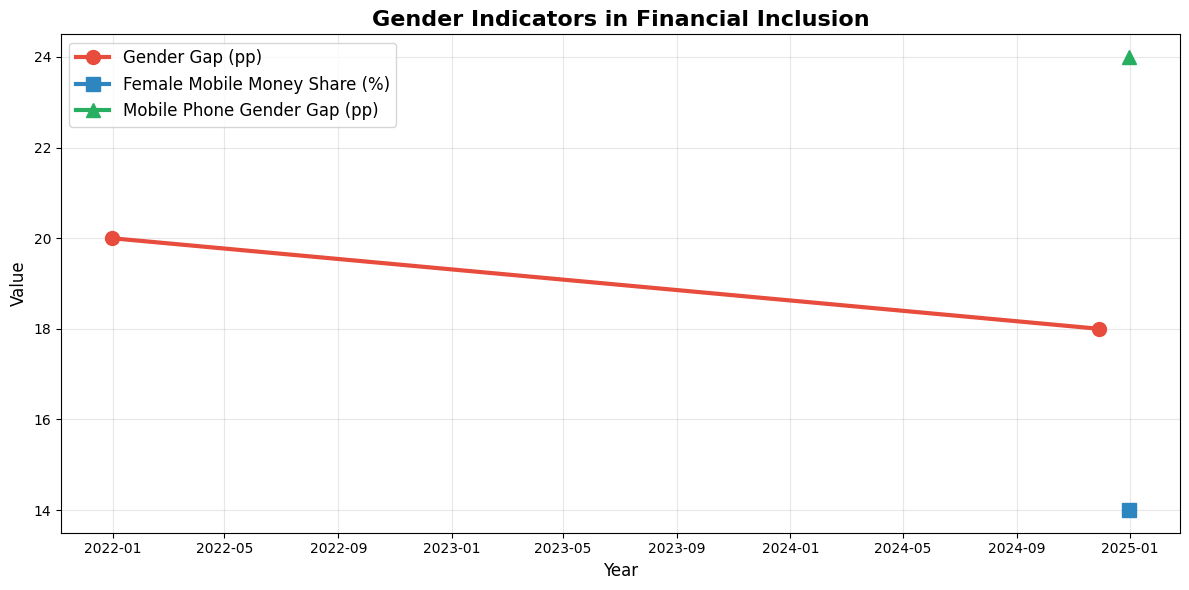


Gender Indicator Summary:
Gender Gap (Account Ownership): [20. 18.]
Female Mobile Money Share: [14.]
Mobile Phone Gender Gap: [24.]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs('reports/figures', exist_ok=True)

print("=" * 80)
print("GENDER ANALYSIS")
print("=" * 80)

from google.colab import files
print("Please upload ethiopia_fi_unified_data.xlsx")
uploaded = files.upload()

df = None
for filename in uploaded.keys():
    if 'ethiopia_fi_unified_data' in filename:
        df = pd.read_excel(filename)
        print(f"Data loaded: {df.shape}")
        break

if df is None:
    print("Error: Could not load data")
    exit()

observations = df[df['record_type'] == 'observation']

gender_data = observations[observations['pillar'] == 'GENDER']

print("\nGender Indicators Available:")
print(gender_data[['indicator_code', 'indicator', 'value_numeric', 'observation_date', 'gender']])

plt.figure(figsize=(12, 6))

gender_gap = gender_data[gender_data['indicator_code'] == 'GEN_GAP_ACC']
female_share = gender_data[gender_data['indicator_code'] == 'GEN_MM_SHARE']
mobile_gap = gender_data[gender_data['indicator_code'] == 'GEN_GAP_MOBILE']

if len(gender_gap) > 0:
    gender_gap = gender_gap.sort_values('observation_date')
    plt.plot(pd.to_datetime(gender_gap['observation_date']), gender_gap['value_numeric'],
             marker='o', linewidth=3, markersize=10, label='Gender Gap (pp)', color='#e74c3c')

if len(female_share) > 0:
    female_share = female_share.sort_values('observation_date')
    plt.plot(pd.to_datetime(female_share['observation_date']), female_share['value_numeric'],
             marker='s', linewidth=3, markersize=10, label='Female Mobile Money Share (%)', color='#2e86c1')

if len(mobile_gap) > 0:
    mobile_gap = mobile_gap.sort_values('observation_date')
    plt.plot(pd.to_datetime(mobile_gap['observation_date']), mobile_gap['value_numeric'],
             marker='^', linewidth=3, markersize=10, label='Mobile Phone Gender Gap (pp)', color='#27ae60')

plt.title('Gender Indicators in Financial Inclusion', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/02_gender_gap.png', dpi=150, bbox_inches='tight')
print("Gender gap visualization saved to reports/figures/02_gender_gap.png")
plt.show()

print("\nGender Indicator Summary:")
print(f"Gender Gap (Account Ownership): {gender_gap['value_numeric'].values if len(gender_gap)>0 else 'No data'}")
print(f"Female Mobile Money Share: {female_share['value_numeric'].values if len(female_share)>0 else 'No data'}")
print(f"Mobile Phone Gender Gap: {mobile_gap['value_numeric'].values if len(mobile_gap)>0 else 'No data'}")

from google.colab import files
files.download('reports/figures/02_gender_gap.png')

DIGITAL PAYMENT TRENDS
Please upload ethiopia_fi_unified_data.xlsx


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data (6).xlsx
Data loaded: (43, 34)

USAGE Indicators Available:
        indicator_code                   indicator  value_numeric  \
14       USG_P2P_COUNT       P2P Transaction Count   4.970000e+07   
15       USG_P2P_COUNT       P2P Transaction Count   1.283000e+08   
16       USG_P2P_VALUE       P2P Transaction Value   5.777000e+11   
17       USG_ATM_COUNT       ATM Transaction Count   1.193000e+08   
18       USG_ATM_VALUE       ATM Transaction Value   1.561000e+11   
19       USG_CROSSOVER     P2P/ATM Crossover Ratio   1.080000e+00   
20  USG_TELEBIRR_USERS   Telebirr Registered Users   5.484000e+07   
21  USG_TELEBIRR_VALUE  Telebirr Transaction Value   2.380000e+12   
22     USG_MPESA_USERS     M-Pesa Registered Users   1.080000e+07   
23    USG_MPESA_ACTIVE  M-Pesa 90-Day Active Users   7.100000e+06   
24     USG_ACTIVE_RATE  Mobile Money Activity Rate   6.600000e+01   

   observation_date          unit  
14       2

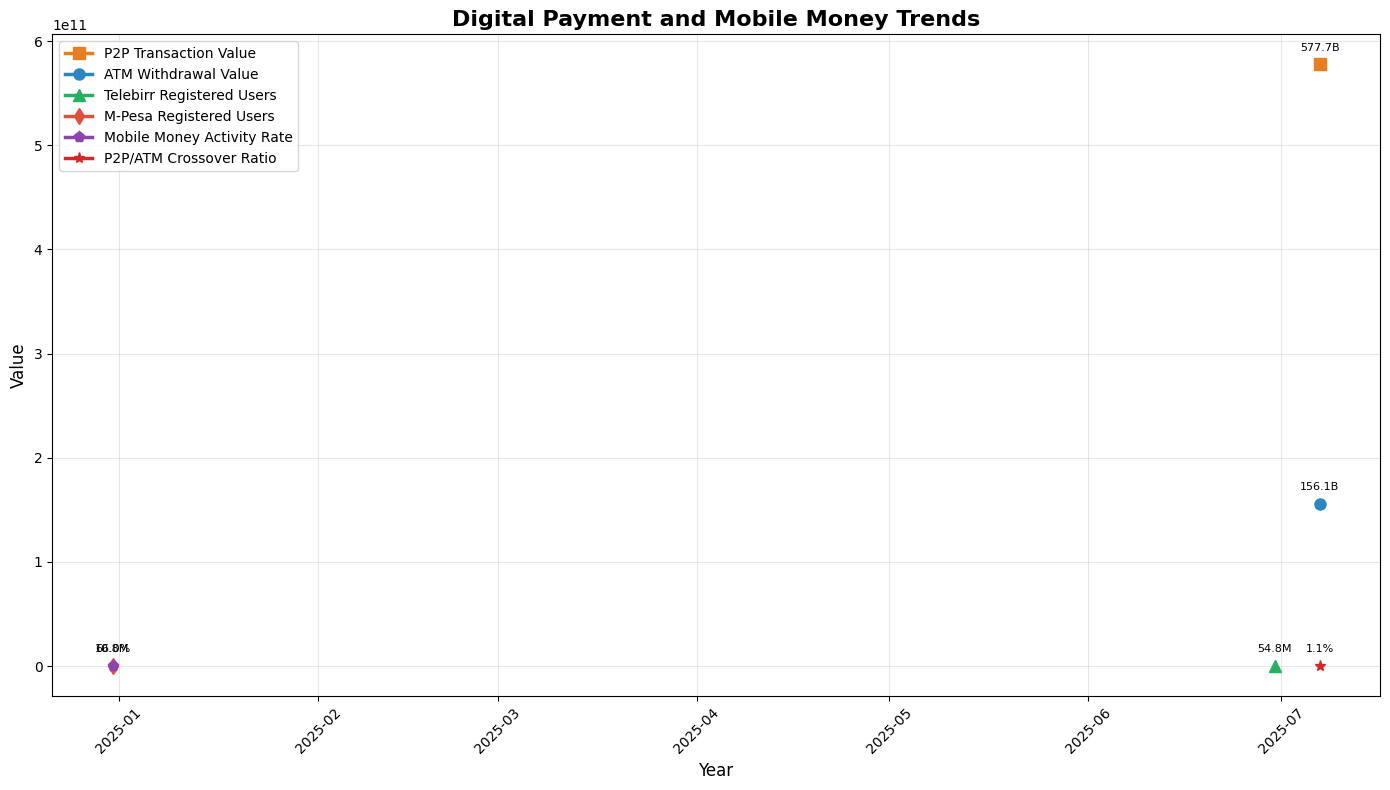


Plotted Indicators:
USG_P2P_VALUE: 1 data points
USG_ATM_VALUE: 1 data points
USG_TELEBIRR_USERS: 1 data points
USG_MPESA_USERS: 1 data points
USG_ACTIVE_RATE: 1 data points
USG_CROSSOVER: 1 data points


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
os.makedirs('reports/figures', exist_ok=True)

print("=" * 80)
print("DIGITAL PAYMENT TRENDS")
print("=" * 80)

from google.colab import files
print("Please upload ethiopia_fi_unified_data.xlsx")
uploaded = files.upload()

df = None
for filename in uploaded.keys():
    if 'ethiopia_fi_unified_data' in filename:
        df = pd.read_excel(filename)
        print(f"Data loaded: {df.shape}")
        break

if df is None:
    print("Error: Could not load data")
    exit()

observations = df[df['record_type'] == 'observation']

usage_data = observations[observations['pillar'] == 'USAGE']

print("\nUSAGE Indicators Available:")
print(usage_data[['indicator_code', 'indicator', 'value_numeric', 'observation_date', 'unit']])

plt.figure(figsize=(14, 8))

indicators = {
    'USG_P2P_VALUE': {'label': 'P2P Transaction Value', 'color': '#e67e22', 'marker': 's'},
    'USG_ATM_VALUE': {'label': 'ATM Withdrawal Value', 'color': '#2e86c1', 'marker': 'o'},
    'USG_TELEBIRR_USERS': {'label': 'Telebirr Registered Users', 'color': '#27ae60', 'marker': '^'},
    'USG_MPESA_USERS': {'label': 'M-Pesa Registered Users', 'color': '#e74c3c', 'marker': 'd'},
    'USG_ACTIVE_RATE': {'label': 'Mobile Money Activity Rate', 'color': '#8e44ad', 'marker': 'p'},
    'USG_CROSSOVER': {'label': 'P2P/ATM Crossover Ratio', 'color': '#d62728', 'marker': '*'},
}

plotted = []
for code, props in indicators.items():
    data = usage_data[usage_data['indicator_code'] == code]
    if len(data) > 0:
        data = data.sort_values('observation_date')
        dates = pd.to_datetime(data['observation_date'])
        values = data['value_numeric'].values

        plt.plot(dates, values,
                 marker=props['marker'], linewidth=2.5, markersize=8,
                 label=props['label'], color=props['color'])
        plotted.append(code)

        for i, (date, val) in enumerate(zip(dates, values)):
            if val > 0:
                if 'USERS' in code:
                    label = f"{val/1000000:.1f}M"
                elif 'VALUE' in code:
                    label = f"{val/1000000000:.1f}B"
                else:
                    label = f"{val:.1f}%"
                plt.annotate(label, (date, val),
                            textcoords="offset points", xytext=(0, 10),
                            ha='center', fontsize=8)

if len(plotted) == 0:
    print("No usage data found. Please check data.")
else:
    plt.title('Digital Payment and Mobile Money Trends', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.legend(fontsize=10, loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('reports/figures/03_digital_payment_trends.png', dpi=150, bbox_inches='tight')
    print(f"\nDigital payment trends saved with {len(plotted)} indicators: {plotted}")
    plt.show()

print("\nPlotted Indicators:")
for code in plotted:
    data = usage_data[usage_data['indicator_code'] == code]
    print(f"{code}: {len(data)} data points")

from google.colab import files
files.download('reports/figures/03_digital_payment_trends.png')

EVENT TIMELINE
Cataloged Events:
                                 indicator        category observation_date
33                         Telebirr Launch  product_launch       2021-05-17
34    Safaricom Ethiopia Commercial Launch    market_entry       2022-08-01
35                  M-Pesa Ethiopia Launch  product_launch       2023-08-01
36        Fayda Digital ID Program Rollout  infrastructure       2024-01-01
37         Foreign Exchange Liberalization          policy       2024-07-29
38     P2P Transaction Count Surpasses ATM       milestone       2024-10-01
39            M-Pesa EthSwitch Integration     partnership       2025-10-27
40  EthioPay Instant Payment System Launch  infrastructure       2025-12-18
41                 NFIS-II Strategy Launch          policy       2021-09-01
42       Safaricom Ethiopia Price Increase         pricing       2025-12-15


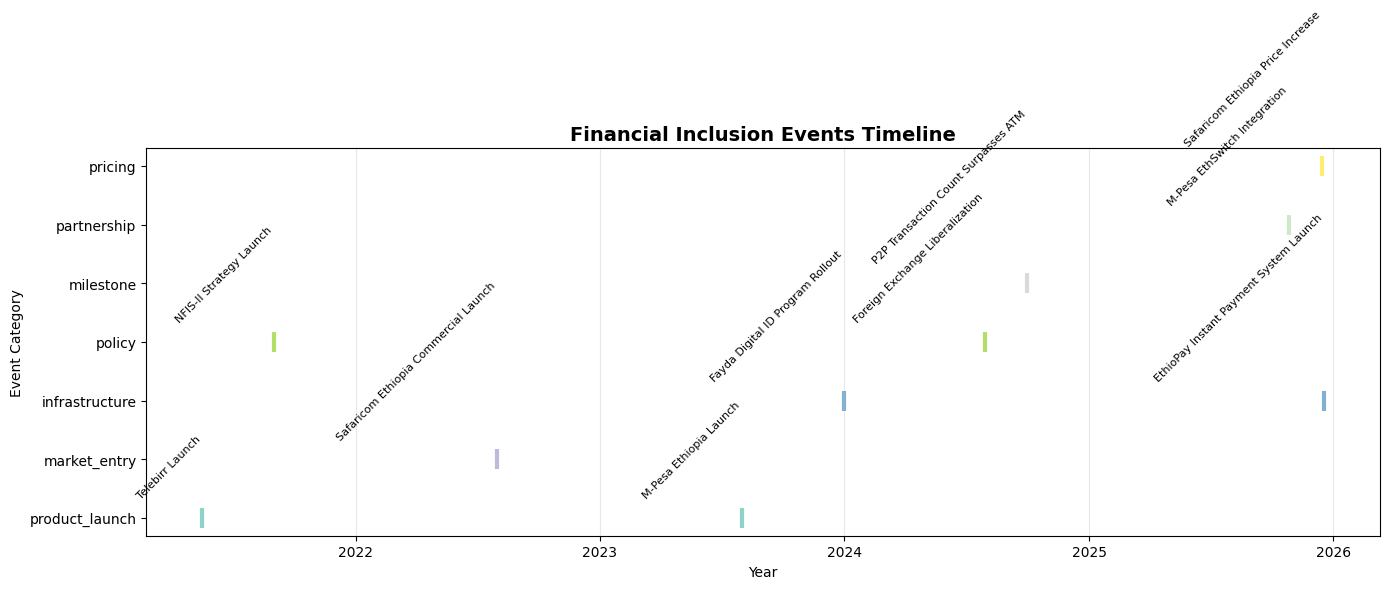

In [ ]:
print("=" * 80)
print("EVENT TIMELINE")
print("=" * 80)

if len(events) > 0:
    print("Cataloged Events:")

    available_cols = []
    for col in ['name', 'category', 'observation_date']:
        if col in events.columns:
            available_cols.append(col)
        elif col == 'name' and 'event_name' in events.columns:
            available_cols.append('event_name')
        elif col == 'name' and 'indicator' in events.columns:
            available_cols.append('indicator')

    print(events[available_cols])

    plt.figure(figsize=(14, 6))

    event_categories = events['category'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(event_categories)))
    color_map = dict(zip(event_categories, colors))

    for idx, event in events.iterrows():
        y_pos = list(event_categories).index(event['category']) * 0.3

        name_col = None
        for col in ['name', 'event_name', 'indicator']:
            if col in events.columns:
                name_col = col
                break

        event_name = event[name_col] if name_col else f"Event {idx}"

        plt.scatter(event['observation_date'], y_pos,
                   s=200, c=[color_map[event['category']]],
                   marker='|', linewidths=3, label=event['category'] if idx == 0 else "")
        plt.text(event['observation_date'], y_pos + 0.1,
                event_name, rotation=45, ha='right', fontsize=8)

    plt.yticks([i * 0.3 for i in range(len(event_categories))], event_categories)
    plt.title('Financial Inclusion Events Timeline', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Event Category')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("No events found")

ACCESS TREND WITH EVENTS OVERLAY


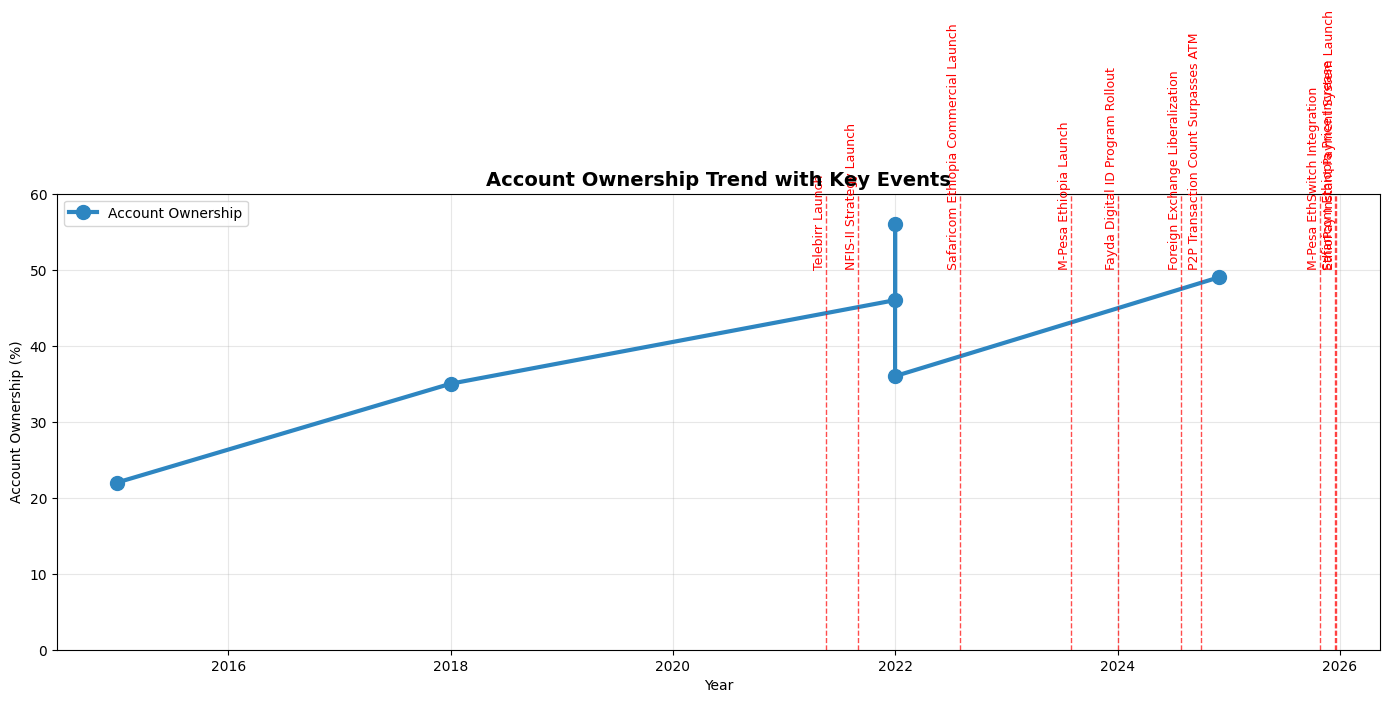

In [ ]:
print("=" * 80)
print("ACCESS TREND WITH EVENTS OVERLAY")
print("=" * 80)

if len(access_ownership) > 0 and len(events) > 0:
    plt.figure(figsize=(14, 7))

    plt.plot(access_ownership['observation_date'], access_ownership['value_numeric'],
            marker='o', linewidth=3, markersize=10, color='#2e86c1', label='Account Ownership')

    name_col = None
    for col in ['name', 'event_name', 'indicator']:
        if col in events.columns:
            name_col = col
            break

    for idx, event in events.iterrows():
        y_max = access_ownership['value_numeric'].max()
        plt.axvline(x=event['observation_date'], color='red', linestyle='--', alpha=0.7, linewidth=1)
        event_name = event[name_col] if name_col else f"Event {idx}"
        plt.text(event['observation_date'], y_max * 0.9,
                event_name, rotation=90, ha='right', fontsize=9, color='red')

    plt.title('Account Ownership Trend with Key Events', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Account Ownership (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 60)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for overlay visualization")

CORRELATION ANALYSIS


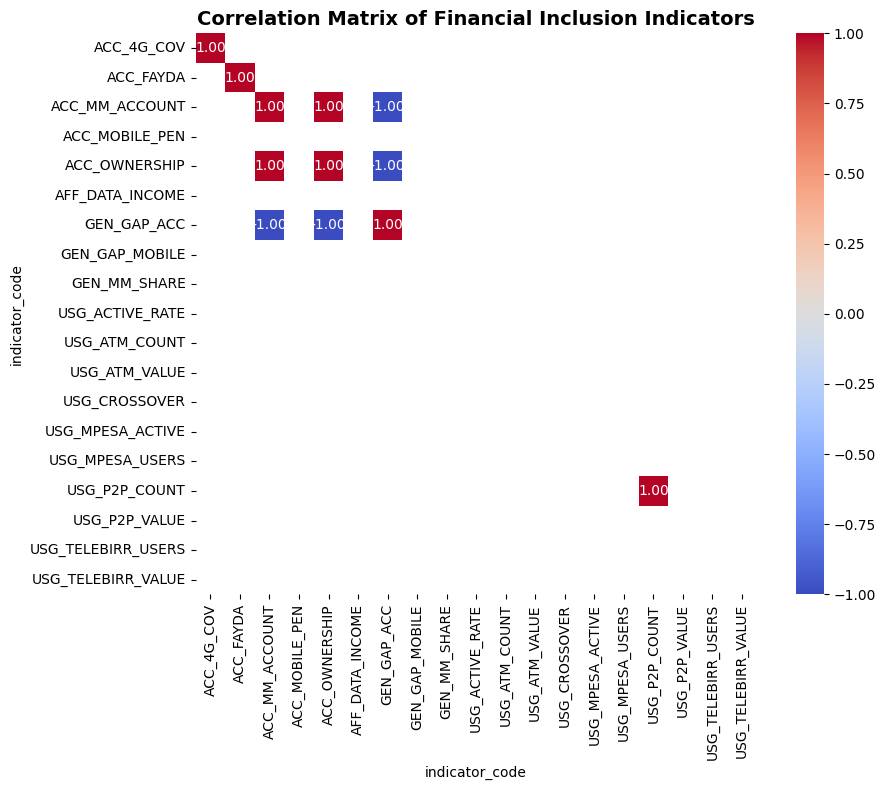


Strongest Correlations with ACC_OWNERSHIP:
indicator_code
ACC_OWNERSHIP         1.0
ACC_MM_ACCOUNT        1.0
GEN_GAP_ACC          -1.0
ACC_4G_COV            NaN
ACC_FAYDA             NaN
ACC_MOBILE_PEN        NaN
AFF_DATA_INCOME       NaN
GEN_GAP_MOBILE        NaN
GEN_MM_SHARE          NaN
USG_ACTIVE_RATE       NaN
USG_ATM_COUNT         NaN
USG_ATM_VALUE         NaN
USG_CROSSOVER         NaN
USG_MPESA_ACTIVE      NaN
USG_MPESA_USERS       NaN
USG_P2P_COUNT         NaN
USG_P2P_VALUE         NaN
USG_TELEBIRR_USERS    NaN
USG_TELEBIRR_VALUE    NaN
Name: ACC_OWNERSHIP, dtype: float64


In [ ]:
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

numeric_obs = observations[['indicator_code', 'value_numeric', 'observation_date']].copy()
numeric_obs['observation_date'] = pd.to_datetime(numeric_obs['observation_date'])

pivot_data = numeric_obs.pivot_table(
    index='observation_date',
    columns='indicator_code',
    values='value_numeric'
)

if len(pivot_data) > 1:
    corr_matrix = pivot_data.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix of Financial Inclusion Indicators', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nStrongest Correlations with ACC_OWNERSHIP:")
    if 'ACC_OWNERSHIP' in corr_matrix.columns:
        correlations = corr_matrix['ACC_OWNERSHIP'].sort_values(ascending=False)
        print(correlations)
else:
    print("Not enough data for correlation analysis")

In [ ]:
print("=" * 80)
print("KEY INSIGHTS SUMMARY")
print("=" * 80)

insights = []

if len(access_ownership) > 0:
    access_data = access_ownership.sort_values('observation_date')
    start_val = access_data.iloc[0]['value_numeric']
    end_val = access_data.iloc[-1]['value_numeric']
    total_change = end_val - start_val
    insights.append(f"Account ownership grew from {start_val}% to {end_val}%, a total increase of {total_change} percentage points")

    if len(access_data) > 1:
        recent_change = access_data.iloc[-1]['value_numeric'] - access_data.iloc[-2]['value_numeric']
        insights.append(f"Latest period (2021-2024) growth: +{recent_change} percentage points")
        if recent_change < 5:
            insights.append(" SLOWDOWN: Growth decelerated significantly in 2021-2024")

if len(gender_data) > 0:
    insights.append("Gender-disaggregated data available for analysis")

if len(events) > 0:
    event_categories = events['category'].value_counts()
    insights.append(f"Events cataloged: {len(events)} across {len(event_categories)} categories")

if len(impact_links) == 0:
    insights.append(" No impact links found - this limits event impact modeling")

print("\n".join(f"• {i}" for i in insights))

print("\n" + "=" * 40)
print("DATA QUALITY ASSESSMENT")
print("=" * 40)

print(f"• Total observations: {len(observations)}")
print(f"• Unique indicators: {observations['indicator_code'].nunique()}")
print(f"• Date range: {observations['observation_date'].min()} to {observations['observation_date'].max()}")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"• Confidence levels available: {df['confidence'].unique().tolist() if 'confidence' in df.columns else 'None'}")

print("\nDATA GAPS IDENTIFIED:")
gaps = []
if len(gender_data) == 0:
    gaps.append("• No gender-disaggregated data")
if len(impact_links) == 0:
    gaps.append("• No impact links defined")
if 'USG_DIGITAL_PAYMENT' not in observations['indicator_code'].unique():
    gaps.append("• No digital payment usage data")
if len(gaps) == 0:
    gaps.append("• No major gaps identified")

print("\n".join(gaps))

KEY INSIGHTS SUMMARY
• Account ownership grew from 22.0% to 49.0%, a total increase of 27.0 percentage points
• Latest period (2021-2024) growth: +13.0 percentage points
• Gender-disaggregated data available for analysis
• Events cataloged: 10 across 7 categories
•  No impact links found - this limits event impact modeling

DATA QUALITY ASSESSMENT
• Total observations: 30
• Unique indicators: 19
• Date range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00
• Missing values: 614
• Confidence levels available: ['high', 'medium']

DATA GAPS IDENTIFIED:
• No impact links defined
• No digital payment usage data


In [ ]:
import os
os.makedirs('reports', exist_ok=True)

with open('reports/eda_summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("EDA SUMMARY - ETHIOPIA FINANCIAL INCLUSION\n")
    f.write("=" * 80 + "\n\n")

    f.write("Dataset Overview:\n")
    f.write(f"  Total records: {len(df)}\n")
    f.write(f"  Observations: {len(observations)}\n")
    f.write(f"  Events: {len(events)}\n")
    f.write(f"  Targets: {len(targets)}\n\n")

    f.write("Access Analysis:\n")
    if len(access_ownership) > 0:
        f.write(f"  Account ownership trend: {access_ownership['value_numeric'].min()}% to {access_ownership['value_numeric'].max()}%\n")

    f.write("\nData Quality:\n")
    f.write(f"  Confidence levels: {df['confidence'].unique().tolist() if 'confidence' in df.columns else 'None'}\n")
    f.write(f"  Missing values: {df.isnull().sum().sum()}\n\n")

    f.write("Key Insights:\n")
    for insight in insights:
        f.write(f"  - {insight}\n")

    f.write("\nData Gaps:\n")
    for gap in gaps:
        f.write(f"  - {gap}\n")

print("EDA summary saved to reports/eda_summary.txt")

from google.colab import files
files.download('reports/eda_summary.txt')

EDA summary saved to reports/eda_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import os
os.makedirs('reports/figures', exist_ok=True)

def save_figure(filename, dpi=150, bbox_inches='tight'):
    plt.savefig(f'reports/figures/{filename}', dpi=dpi, bbox_inches=bbox_inches)
    print(f"Saved: reports/figures/{filename}")

print("=" * 80)
print("SAVING ALL EDA VISUALIZATIONS")
print("=" * 80)

if len(access_ownership) > 0:
    access_ownership_sorted = access_ownership.sort_values('observation_date')
    plt.figure(figsize=(12, 6))
    plt.plot(access_ownership_sorted['observation_date'], access_ownership_sorted['value_numeric'],
             marker='o', linewidth=2, markersize=8, color='#2e86c1')
    plt.title('Ethiopia Account Ownership Trend (2014-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Account Ownership (%)')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 60)
    for i, row in access_ownership_sorted.iterrows():
        plt.annotate(f"{row['value_numeric']:.0f}%",
                    (row['observation_date'], row['value_numeric']),
                    textcoords="offset points", xytext=(0,10), ha='center')
    plt.tight_layout()
    save_figure('01_account_ownership_trend.png')
    plt.close()

if len(gender_data) > 0:
    gender_pivot = gender_data.pivot_table(
        index='observation_date',
        columns='gender',
        values='value_numeric'
    )
    if len(gender_pivot) > 0:
        plt.figure(figsize=(12, 6))
        for col in gender_pivot.columns:
            plt.plot(gender_pivot.index, gender_pivot[col],
                    marker='o', linewidth=2, label=col)
        plt.title('Gender Gap in Financial Inclusion', fontsize=14, fontweight='bold')
        plt.xlabel('Year')
        plt.ylabel('Account Ownership (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_figure('02_gender_gap.png')
        plt.close()

usage_data = observations[observations['pillar'] == 'USAGE']
if len(usage_data) > 0:
    digital_payment = usage_data[usage_data['indicator_code'] == 'USG_DIGITAL_PAYMENT']
    mobile_money = usage_data[usage_data['indicator_code'] == 'USG_MOBILE_MONEY']

    plt.figure(figsize=(12, 6))
    if len(digital_payment) > 0:
        digital_payment = digital_payment.sort_values('observation_date')
        plt.plot(digital_payment['observation_date'], digital_payment['value_numeric'],
                marker='s', linewidth=2, markersize=8, label='Digital Payment', color='#e67e22')
    if len(mobile_money) > 0:
        mobile_money = mobile_money.sort_values('observation_date')
        plt.plot(mobile_money['observation_date'], mobile_money['value_numeric'],
                marker='^', linewidth=2, markersize=8, label='Mobile Money', color='#27ae60')
    plt.title('Digital Payment Adoption Trends', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Adoption (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure('03_digital_payment_trends.png')
    plt.close()

if len(events) > 0:
    plt.figure(figsize=(14, 6))
    event_categories = events['category'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(event_categories)))
    color_map = dict(zip(event_categories, colors))

    name_col = None
    for col in ['name', 'event_name', 'indicator']:
        if col in events.columns:
            name_col = col
            break

    for idx, event in events.iterrows():
        y_pos = list(event_categories).index(event['category']) * 0.3
        event_name = event[name_col] if name_col else f"Event {idx}"
        plt.scatter(event['observation_date'], y_pos,
                   s=200, c=[color_map[event['category']]],
                   marker='|', linewidths=3)
        plt.text(event['observation_date'], y_pos + 0.1,
                event_name, rotation=45, ha='right', fontsize=8)

    plt.yticks([i * 0.3 for i in range(len(event_categories))], event_categories)
    plt.title('Financial Inclusion Events Timeline', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Event Category')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    save_figure('04_event_timeline.png')
    plt.close()

if len(access_ownership) > 0 and len(events) > 0:
    plt.figure(figsize=(14, 7))
    plt.plot(access_ownership['observation_date'], access_ownership['value_numeric'],
            marker='o', linewidth=3, markersize=10, color='#2e86c1', label='Account Ownership')

    name_col = None
    for col in ['name', 'event_name', 'indicator']:
        if col in events.columns:
            name_col = col
            break

    for idx, event in events.iterrows():
        y_max = access_ownership['value_numeric'].max()
        plt.axvline(x=event['observation_date'], color='red', linestyle='--', alpha=0.7, linewidth=1)
        event_name = event[name_col] if name_col else f"Event {idx}"
        plt.text(event['observation_date'], y_max * 0.9,
                event_name, rotation=90, ha='right', fontsize=9, color='red')

    plt.title('Account Ownership Trend with Key Events', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Account Ownership (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 60)
    plt.tight_layout()
    save_figure('05_access_with_events.png')
    plt.close()

if len(pivot_data) > 1:
    corr_matrix = pivot_data.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Correlation Matrix of Financial Inclusion Indicators', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_figure('06_correlation_matrix.png')
    plt.close()

plt.figure(figsize=(10, 6))
pillar_counts = observations['pillar'].value_counts()
pillar_counts.plot(kind='bar', color=['#2e86c1', '#e67e22', '#27ae60', '#8e44ad'])
plt.title('Distribution of Observations by Pillar', fontsize=14, fontweight='bold')
plt.xlabel('Pillar')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_figure('07_pillar_distribution.png')
plt.close()

print("\n" + "=" * 40)
print("ALL FIGURES SAVED")
print("=" * 40)

SAVING ALL EDA VISUALIZATIONS
Saved: reports/figures/01_account_ownership_trend.png
Saved: reports/figures/02_gender_gap.png
Saved: reports/figures/03_digital_payment_trends.png
Saved: reports/figures/04_event_timeline.png
Saved: reports/figures/05_access_with_events.png
Saved: reports/figures/06_correlation_matrix.png
Saved: reports/figures/07_pillar_distribution.png

ALL FIGURES SAVED


In [ ]:
print("=" * 80)
print("DOWNLOAD INDIVIDUAL FIGURES")
print("=" * 80)

figures = [f for f in os.listdir('reports/figures') if f.endswith('.png')]

for fig in figures:
    print(f"Downloading: {fig}")
    files.download(f'reports/figures/{fig}')

print("\nAll figures downloaded individually")

DOWNLOAD INDIVIDUAL FIGURES
Downloading: 03_digital_payment_trends.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: 04_event_timeline.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: 01_account_ownership_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All figures downloaded individually
